In [282]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from utils.plot_reader import *
from utils.helper_functions import root_polyfit

In [283]:
df_chr_BPIX = get_charge_plot_BPIX_data()
df_chr_FPIX = get_charge_plot_FPIX_data()
df_eff = get_efficiency_plot_data()
df_lines = get_lines_data()

# merge efficiency and charge data on "x"
df = pd.merge(df_eff, df_chr_FPIX, on="x", how="outer").dropna().sort_values("x")
df = pd.merge(df, df_chr_BPIX, on="x", how="outer").dropna().sort_values("x")

# normalize charge values to max
# max_chr = 22.941295 # y2_chr_FPIX
# for col in df.columns:
#     if col.startswith('y') and 'chr' in col:
#         df[col] = df[col].astype(float) / max_chr

Total TLine objects: 19


#### Start: Scatter efficiency and svis slope

In [284]:
data = pd.read_csv('csvs/final_fit_Run3.csv')

# Find nearest lumi index
data_lumi = data["integrated_lumi"].values

def nearest_eff(lumi):
    idx = np.abs(data_lumi - lumi).argmin()
    return data.iloc[idx]["final_ratio"]

df["final_ratio"] = df["x"].apply(nearest_eff)

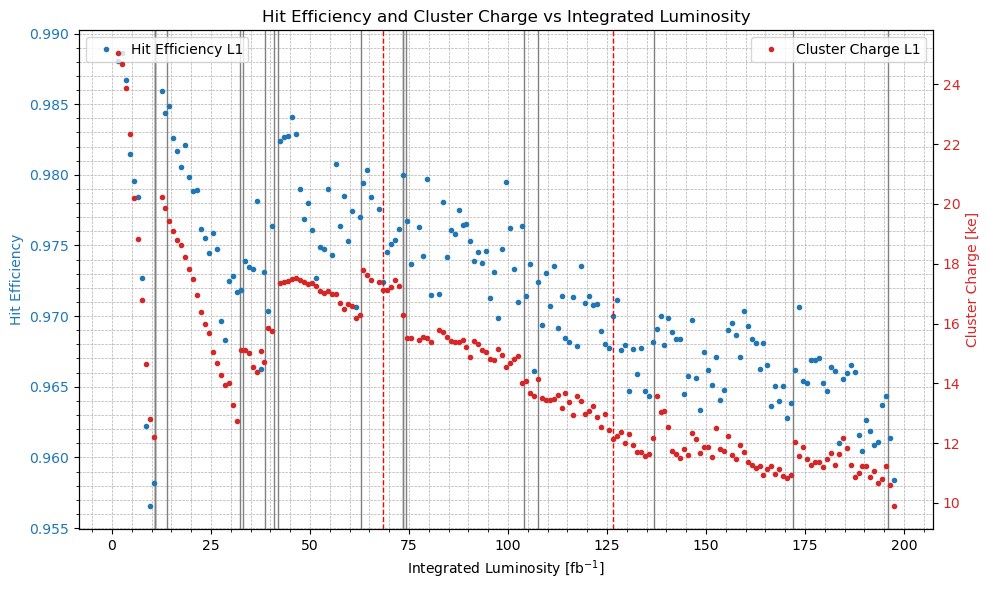

In [285]:
# plot efficiency and charge vs x with error bars
fig, ax1 = plt.subplots(figsize=(10, 6))
color_eff = 'tab:blue'
ax1.set_xlabel('Integrated Luminosity [fb$^{-1}$]')
ax1.set_ylabel('Hit Efficiency', color=color_eff)
ax1.errorbar(df["x"], df["y1_eff"], fmt='.', color=color_eff, label='Hit Efficiency L1')
# ax1.errorbar(df["x"], df["y2_eff"], fmt='.', color="cyan", label='Hit Efficiency L2')
ax1.tick_params(axis='y', labelcolor=color_eff)
# ax1.set_ylim(0.3, 1.05)
ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
# add minor ticks
ax1.minorticks_on()
ax1.legend(loc='upper left')
ax1.set_title('Hit Efficiency and Cluster Charge vs Integrated Luminosity')
ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
color_chr = 'tab:red'
ax2.set_ylabel('Cluster Charge [ke]', color=color_chr)
ax2.errorbar(df["x"], df["y1_chr_BPIX"], fmt='.', color=color_chr, label='Cluster Charge L1')
# ax2.errorbar(df["x"], df["y2_chr_BPIX"], fmt='.', color="brown", label='Cluster Charge L2')
ax2.tick_params(axis='y', labelcolor=color_chr)
# ax2.set_ylim(0.3, 1.05)
ax2.legend(loc='upper right')
# add vertical lines from df_lines
for _, row in df_lines.iterrows():
    if row["orientation"] == "vertical":
        ax1.axvline(x=row["x1"], color='gray', linestyle='--' if row["style"] == 2 else (':' if row["style"] == 3 else '-'), linewidth=1)
        # if row["label"] != "Other":
        #     ax1.text(row["x1"], ax1.get_ylim()[1]*0.95, row["label"], rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=8, color='gray')
fig.tight_layout()
# draw vertical line at x=50
plt.axvline(x=68.5, color='red', linestyle='--', linewidth=1)
plt.axvline(x=126.5, color='red', linestyle='--', linewidth=1)


Text(0, 0.5, 'J/$\\Psi$ Lumi. / Ref. Lumi.')

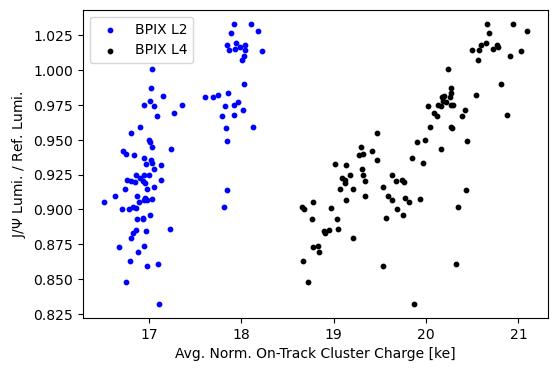

In [310]:
# only plot integrated lumi from 75 - 173
scatter_df = df[(df["x"] >=75) & (df["x"] <= 173)]

plt.figure(figsize=(6, 4))
# plt.scatter( df['y1_chr_BPIX'], df['final_ratio'], label='BPIX L1', color='black', s=10)

plt.scatter( scatter_df['y2_chr_BPIX'], scatter_df['final_ratio'], label='BPIX L2', color='blue', s=10)
plt.scatter( scatter_df['y4_chr_BPIX'], scatter_df['final_ratio'], label='BPIX L4', color='k', s=10)

# plt.scatter( df['y1_eff'], df['final_ratio'], label='BPIX L1', color='black', s=10)
# plt.scatter( df['y2_eff'], df['final_ratio'], label='BPIX L2', color='blue', s=10)

plt.legend()
plt.xlabel('Avg. Norm. On-Track Cluster Charge [ke]')
# plt.xlabel('Hit Efficiency')
plt.ylabel('J/$\Psi$ Lumi. / Ref. Lumi.')
# plt.xlim(0.95, 1)
# plt.xlim(10, 22)
# plt.ylim(0.8, 1.05)

(0.7, 1.2)

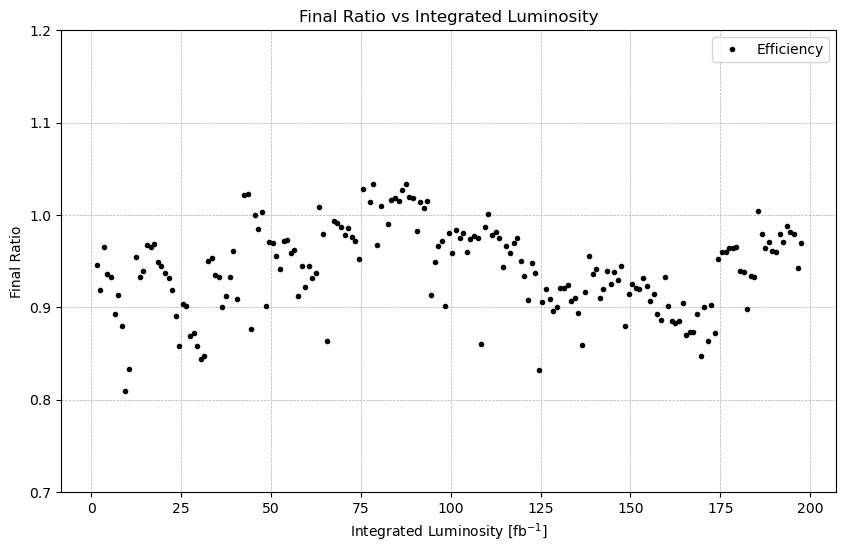

In [287]:
plt.figure(figsize=(10, 6))
plt.plot(df['x'], df['final_ratio'], '.', label='Efficiency', color='black')
plt.xlabel('Integrated Luminosity [fb$^{-1}$]')
plt.ylabel('Final Ratio')
plt.title('Final Ratio vs Integrated Luminosity')
plt.legend()
plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.ylim(0.7, 1.2)

#### End: Efficiency and svis slope study

In [288]:
df_chr_BPIX['avg'] = (df_chr_BPIX['y1_chr_BPIX'] + df_chr_BPIX['y2_chr_BPIX'] + df_chr_BPIX['y3_chr_BPIX'] + df_chr_BPIX['y4_chr_BPIX'])/4

In [289]:
# plt.plot(df_chr_BPIX['x'], df_chr_BPIX['y1_chr_BPIX'], '.', label=col)
# plt.ylim([0, 35])
# for col in ['y1_chr_BPIX', 'y2_chr_BPIX', 'y3_chr_BPIX', 'y4_chr_BPIX']:
#     plt.plot(df['x'], df[col], '.', label=col)

In [290]:
# # plot efficiency and charge vs x with error bars
# fig, ax1 = plt.subplots(figsize=(10, 6))
# color_eff = 'tab:blue'
# ax1.set_xlabel('Integrated Luminosity [fb$^{-1}$]')
# ax1.set_ylabel('Hit Efficiency$^2$', color=color_eff)
# ax1.errorbar(df["x"], df["y_eff_sq"], yerr=df["yerr_eff"], fmt='.', color=color_eff, label='Hit Efficiency$^2$')
# ax1.tick_params(axis='y', labelcolor=color_eff)
# ax1.set_ylim(0.3, 1.05)
# ax1.grid(True, which='both', linestyle='--', linewidth=0.5)
# ax1.legend(loc='upper left')
# ax1.set_title('Hit Efficiency$^2$ and Average On-Cluster Charge vs Integrated Luminosity')
# ax2 = ax1.twinx()  # instantiate a second axes that shares the same x-axis
# color_chr = 'tab:red'
# ax2.set_ylabel('Average On-Cluster Charge [ke]', color=color_chr)
# ax2.errorbar(df["x"], df["y_chr_BPIX_sq"], yerr=df["yerr_chr_BPIX"], fmt='.', color=color_chr, label='Avg On-Cluster Charge$^2$')
# ax2.tick_params(axis='y', labelcolor=color_chr)
# ax2.set_ylim(0.3, 1.05)
# ax2.legend(loc='upper right')
# # add vertical lines from df_lines
# for _, row in df_lines.iterrows():
#     if row["orientation"] == "vertical":
#         ax1.axvline(x=row["x1"], color='gray', linestyle='--' if row["style"] == 2 else (':' if row["style"] == 3 else '-'), linewidth=1)
#         # if row["label"] != "Other":
#         #     ax1.text(row["x1"], ax1.get_ylim()[1]*0.95, row["label"], rotation=90, verticalalignment='top', horizontalalignment='right', fontsize=8, color='gray')
# fig.tight_layout()

In [291]:
import ast

# read ntuples as ntuples
data_region_summary = pd.read_csv("data_fit_summary_Run3.csv")
data_region_summary['coeff_data'] = data_region_summary['coeff_data'].apply(ast.literal_eval)
data_region_summary['run_range'] = data_region_summary['run_range'].apply(ast.literal_eval)
data_region_summary['int_lumi_range'] = data_region_summary['int_lumi_range'].apply(ast.literal_eval)

data_region_summary

,region,coeff_data,sigma,n_points,run_range,int_lumi_range
0,2024a,"(-0.002331735205800725, 1.0)","[0.00014411187697925778, 0.0024726039809270855]",1502,"(379416, 381544)","(74.98679337792825, 105.04793697590138)"
1,2024b,"(-0.002781643267830591, 1.0)","[7.203276024525343e-05, 0.0013364894308142185]",1417,"(382251, 383855)","(105.39032592192488, 137.8786325105323)"
2,2024c,"(-0.0015407308406327602, 1.0)","[5.941670883828747e-05, 0.0012289916363455897]",1444,"(383907, 385515)","(137.91739082554855, 173.07735836901222)"


In [292]:
# # Define which individual columns correspond to each averaged one
# bpix_cols = ["y3_chr_BPIX"]#, "y2_chr_BPIX", "y3_chr_BPIX", "y4_chr_BPIX"]
# # eff_cols  = ["y2_eff"]

# all_cols = bpix_cols

# plt.figure(figsize=(10, 6))
# for row in data_region_summary.itertuples():
#     region_mask = (df["x"] >= row.int_lumi_range[0]) & (df["x"] <= row.int_lumi_range[1])
#     region_df = df[region_mask]
#     xx_orig = region_df["x"]
#     xx = xx_orig - min(xx_orig)
#     x_fit = np.linspace(min(xx), max(xx), 100)

#     # # # ---- plot fit lines ---- 
#     # coeff_data = list(row.coeff_data)
#     # y_fit_data = np.polyval(coeff_data, x_fit)
#     # plt.plot(x_fit + min(xx_orig), y_fit_data, '-.b', lw=2, label=f"Required")

#     # ---- Plot individual columns ----
#     for col in all_cols:
#         assert col in region_df.columns, f"Column {col} not found in DataFrame"
#         yy = region_df[col]
#         assert not yy.isnull().any(), f"Column {col} contains NaN values in the selected region"
#         yy = yy**2
#         if len(yy) > 15:
#             coeffs, sigma, res = root_polyfit(xx, yy, degree=1)
#         else:
#             coeffs, sigma, res = root_polyfit(xx, yy, degree=0)
#             print(coeffs, sigma, res)

#         coeffs = np.array(coeffs)
#         # normalization = coeffs[-1]
#         # coeffs = coeffs / normalization
#         # yy = yy / normalization

#         yy_fit = np.polyval(coeffs, x_fit)
#         print(f"{row.region}, Column {col}, Coefficients: {coeffs}")
#         print(yy_fit[0], yy_fit[-1])
#         plt.plot(x_fit + min(xx_orig), yy_fit, '--', lw=1, label=f"{col}^2")
#         plt.plot(xx_orig, yy, 'o', ms=4)#, label=f"{col}")

# plt.grid(True, which='both', linestyle='--', linewidth=0.5)
# plt.xlabel("Int. lumi")
# plt.legend()


****************************************
Minimizer is Linear / Migrad
Chi2                      =      326.184
NDf                       =           26
p0                        =      376.515   +/-   1.38986     
p1                        =     -1.24544   +/-   0.0796861   

****************************************
Minimizer is Linear / Migrad
Chi2                      =      179.226
NDf                       =           31
p0                        =      349.147   +/-   0.818454    
p1                        =     -1.34022   +/-   0.043958    

****************************************
Minimizer is Linear / Migrad
Chi2                      =       616.51
NDf                       =           33
p0                        =      304.875   +/-   1.43043     
p1                        =    -0.844332   +/-   0.0723401   


Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created


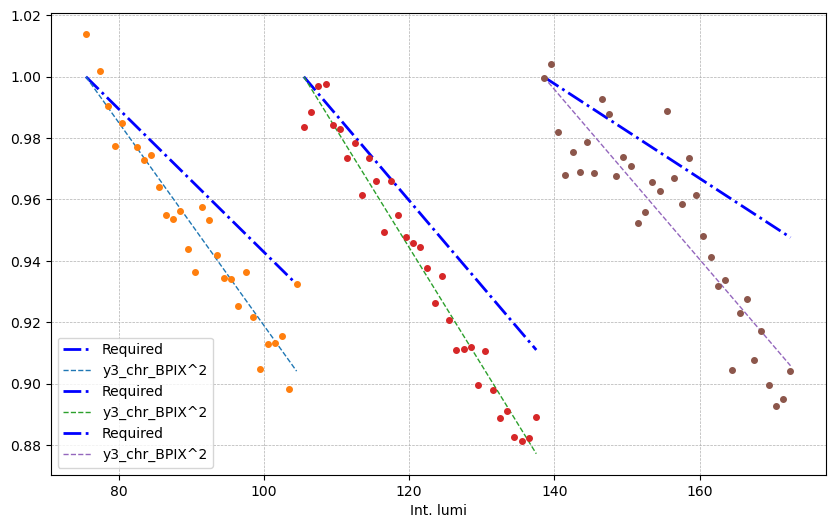

In [293]:
# Define which individual columns correspond to each averaged one
# bpix_cols = ["y1_chr_BPIX", "y2_chr_BPIX", "y3_chr_BPIX", "y4_chr_BPIX"]
bpix_cols = ["y3_chr_BPIX"]
fpix_cols = ["y1_chr_FPIX", "y2_chr_FPIX", "y3_chr_FPIX"]
eff_cols  = ["y1_eff", "y2_eff"]

all_cols = bpix_cols #+ fpix_cols #+ eff_cols
# all_cols = fpix_cols
# all_cols = eff_cols

plt.figure(figsize=(10, 6))
for row in data_region_summary.itertuples():
    region_mask = (df["x"] >= row.int_lumi_range[0]) & (df["x"] <= row.int_lumi_range[1])
    region_df = df[region_mask]
    xx_orig = region_df["x"]
    xx = xx_orig - min(xx_orig)
    x_fit = np.linspace(min(xx), max(xx), 100)

    # # ---- plot fit lines ---- 
    coeff_data = list(row.coeff_data)
    y_fit_data = np.polyval(coeff_data, x_fit)
    plt.plot(x_fit + min(xx_orig), y_fit_data, '-.b', lw=2, label=f"Required")

    # ---- Plot individual columns ----
    for col in all_cols:
        assert col in region_df.columns, f"Column {col} not found in DataFrame"
        yy = region_df[col]
        assert not yy.isnull().any(), f"Column {col} contains NaN values in the selected region"
        yy = yy**2
        if len(yy) > 15:
            coeffs, sigma, res = root_polyfit(xx, yy, degree=1)
        else:
            coeffs, sigma, res = root_polyfit(xx, yy, degree=0)
            print(coeffs, sigma, res)

        coeffs = np.array(coeffs)
        normalization = coeffs[-1]
        coeffs = coeffs / normalization
        yy = yy / normalization

        yy_fit = np.polyval(coeffs, x_fit)
        plt.plot(x_fit + min(xx_orig), yy_fit, '--', lw=1, label=f"{col}^2")
        plt.plot(xx_orig, yy, 'o', ms=4)#, label=f"{col}")

    # ---- plot scaled slopes ----
    # coeff_data = list(row.coeff_data)
    # slope_data = coeff_data[0]
    # plt.plot(xx_orig, (np.zeros_like(xx_orig) + slope_data)/slope_data, '-.b', lw=2, label=f"Required slope")

    # # ---- Plot individual columns ----
    # for col in all_cols:
    #     assert col in region_df.columns, f"Column {col} not found in DataFrame"
    #     yy = region_df[col]
    #     assert not yy.isnull().any(), f"Column {col} contains NaN values in the selected region"
    #     yy = yy**2
    #     coeffs, sigma = root_polyfit(xx, yy, degree=1)

    #     slope = coeffs[0]
    #     plt.plot(xx_orig, (np.zeros_like(xx_orig) + slope)/slope_data, '-', lw=1, label=f"{col}^2")


plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel("Int. lumi")
plt.legend()

Region: 2024a, Coefficients combined: [-0.00277565  1.        ]


Region: 2024b, Coefficients combined: [-0.00241522  1.        ]
Region: 2024c, Coefficients combined: [-0.0023551  1.       ]

****************************************
Minimizer is Linear / Migrad
Chi2                      =      57.7083
NDf                       =           26
p0                        =      442.371   +/-   0.584602    
p1                        =     -1.22787   +/-   0.0335174   

****************************************
Minimizer is Linear / Migrad
Chi2                      =      100.267
NDf                       =           31
p0                        =      413.144   +/-   0.612173    
p1                        =    -0.997837   +/-   0.032879    

****************************************
Minimizer is Linear / Migrad
Chi2                      =      45.7871
NDf                       =           33
p0                        =      378.767   +/-   0.389824    
p1                        =    -0.892034   +/-   0.0197143   


Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created
Info in <TCanvas::Print>: png file root_polyfit.png has been created


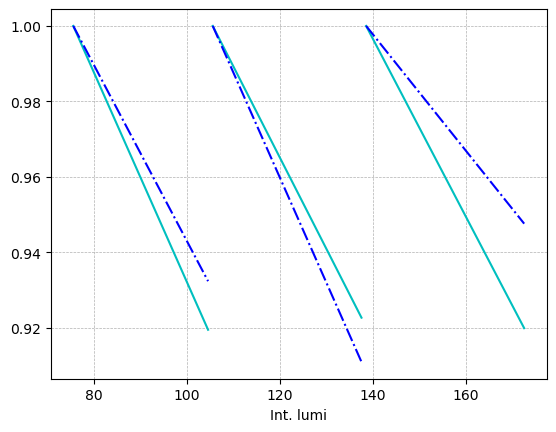

In [294]:
plot_region = []
plot_coeff_chr_BPIX = []
plot_coeff_chr_FPIX = []
plot_coeff_eff = []
plot_coeff_combined = []

for row in data_region_summary.itertuples():
    region_mask = (df["x"] >= row.int_lumi_range[0]) & (df["x"] <= row.int_lumi_range[1])
    region_df = df[region_mask]
    xx_orig = region_df["x"]
    xx = xx_orig - min(xx_orig)

    degree = 1

    # yy_combined =  0.73 * yy_ch_BPIX**2 + 0.17 * yy_ch_FPIX**2 + 0.10 * (yy_ch_BPIX * yy_ch_FPIX)
    # k = 0.95
    # yy_combined = k*region_df['y2_chr_BPIX']**2 + (1-k)*region_df['y1_chr_BPIX']**2
    yy_combined = region_df['y4_chr_BPIX']**2
    # yy_combined = region_df['y1_eff']**2
    # yy_combined = region_df['y1_chr_BPIX']**2
    # yy_combined = region_df['coeffs_data']**2
    # yy_combined = k*region_df['y1_chr_FPIX']**2 + (1-k)*region_df['y1_chr_BPIX']**2

    if len(yy_combined) > 15:
        coeffs_combined, sigma, res = root_polyfit(xx, yy_combined, degree=degree)
    else:
        coeffs_combined, sigma, res = root_polyfit(xx, yy_combined, degree=0)
        # add slope to the front
        coeffs_combined = [0.0] + coeffs_combined
        sigma = [0.0] + sigma

    coeffs_combined = np.array(coeffs_combined)
    coeffs_combined = coeffs_combined / coeffs_combined[-1]
    # coeffs_combined = [-0.003307801783736942, 1.0] # from 2024a: use single fit through all regions

    print(f"Region: {row.region}, Coefficients combined: {coeffs_combined}")

    # Plot the fit
    x_fit = np.linspace(min(xx), max(xx), 100)
    y_fit_combined = np.polyval(coeffs_combined, x_fit)

    # plt.plot(x_fit + min(xx_orig), y_fit_eff, '-g', label=f"{row.region} Efficiency Fit")
    plt.plot(x_fit + min(xx_orig), y_fit_combined, '-c', label=f"{row.region} Combined Fit")
    # plt.errorbar(xx_orig, yy_combined, fmt='.r', label=f"{row.region} Charge BPIX Data")

    coeff_data = list(row.coeff_data)
    y_fit_data = np.polyval(coeff_data, x_fit)
    plt.plot(x_fit + min(xx_orig), y_fit_data, '-.b')

    plot_region.append(row.region)
    # plot_coeff_chr_BPIX.append(tuple(coeffs_chr_BPIX))
    # plot_coeff_chr_FPIX.append(tuple(coeffs_chr_FPIX))
    # plot_coeff_eff.append(tuple(coeffs_eff))
    plot_coeff_combined.append(tuple(coeffs_combined))

plt.grid(True, which='both', linestyle='--', linewidth=0.5)
plt.xlabel("Int. lumi")
# plt.ylim([0.5, 1.1])

plot_df = pd.DataFrame({
    "region": plot_region,
    # "coeff_chr_BPIX": plot_coeff_chr_BPIX,
    # "coeff_chr_FPIX": plot_coeff_chr_FPIX,
    # "coeff_eff": plot_coeff_eff,
    "coeff_combined": plot_coeff_combined
})
# plot_df

In [295]:
final_summary = pd.merge(data_region_summary, plot_df, on='region', how='inner')
final_summary
final_summary.to_csv("data_fit_summary_Run3_with_plot_coeff.csv", index=False)

In [296]:
final_summary

,region,coeff_data,sigma,n_points,run_range,int_lumi_range,coeff_combined
0,2024a,"(-0.002331735205800725, 1.0)","[0.00014411187697925778, 0.0024726039809270855]",1502,"(379416, 381544)","(74.98679337792825, 105.04793697590138)","(-0.0027756520999642604, 1.0)"
1,2024b,"(-0.002781643267830591, 1.0)","[7.203276024525343e-05, 0.0013364894308142185]",1417,"(382251, 383855)","(105.39032592192488, 137.8786325105323)","(-0.0024152248459754348, 1.0)"
2,2024c,"(-0.0015407308406327602, 1.0)","[5.941670883828747e-05, 0.0012289916363455897]",1444,"(383907, 385515)","(137.91739082554855, 173.07735836901222)","(-0.0023550962110604205, 1.0)"


In [297]:
# Extract 2nd elements
df_extract = pd.DataFrame({
    "region": final_summary["region"],
    "coeff_data_second": final_summary["coeff_data"].apply(lambda x: x[1]),
    "coeff_combined_second": final_summary["coeff_combined"].apply(lambda x: x[1])
})

print(df_extract)

  region  coeff_data_second  coeff_combined_second
0  2024a                1.0                    1.0
1  2024b                1.0                    1.0
2  2024c                1.0                    1.0


Text(0, 0.5, 'BPIX layer 1 intercept')

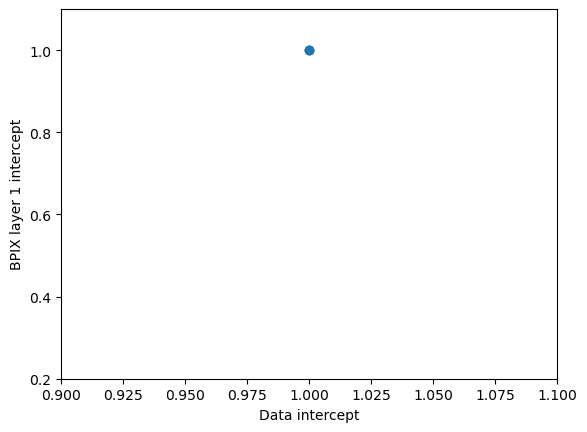

In [298]:
plt.scatter(df_extract["coeff_data_second"], df_extract["coeff_combined_second"])
plt.xlim(0.9, 1.1)
plt.ylim(0.2, 1.1)
plt.xlabel("Data intercept")
plt.ylabel("BPIX layer 1 intercept")

In [299]:
# plt.figure()
# for row in final_summary.itertuples():
#     plt.plot(row.int_lumi_range, [row.coeff_chr_BPIX[1], row.coeff_chr_BPIX[1]], 'r')
#     plt.plot(row.int_lumi_range, [row.coeff_chr_FPIX[1], row.coeff_chr_FPIX[1]], 'm')
#     plt.plot(row.int_lumi_range, [row.coeff_combined[1], row.coeff_combined[1]], 'c')
#     plt.plot(row.int_lumi_range, [row.coeff_data[1], row.coeff_data[1]], 'b')

#     # plt.plot(row.int_lumi_range, [row.coeff_data[0]*x + row.coeff_data[1] for x in row.int_lumi_range], 'g--', label='Slope')
#     plt.text(np.mean(row.int_lumi_range), row.coeff_data[1]+0.0002,
#              f"{row.region}",
#              ha='center', va='bottom', fontsize=8, rotation=0)

# plt.xlabel('Integrated Luminosity (fb$^{-1}$)')
# plt.ylabel('Slope of MLE Fit')
# plt.title('Slope of MLE Fit by Data Region')
# plt.legend(['Charge Fit Slope BPIX', 'Charge Fit Slope FPIX', 'combined slope', 'Required slope'])
# # plt.grid()
# plt.ylim(-0.013, 0.003)
# plt.tight_layout()